In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/cleaned_house_prices.csv")
print(df['SalePrice'].describe())
print("Skewness:", df['SalePrice'].skew())

count      1458.000000
mean     180932.919067
std       79495.055285
min       34900.000000
25%      129925.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64
Skewness: 1.8812964895244009


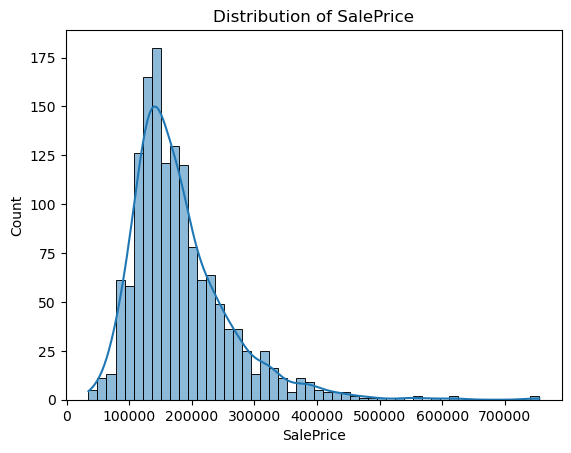

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['SalePrice'], kde=True, bins=50)
plt.title('Distribution of SalePrice')
plt.show()

Original SalePrice Skewness: 1.88
Log-transformed SalePrice Skewness: 0.12


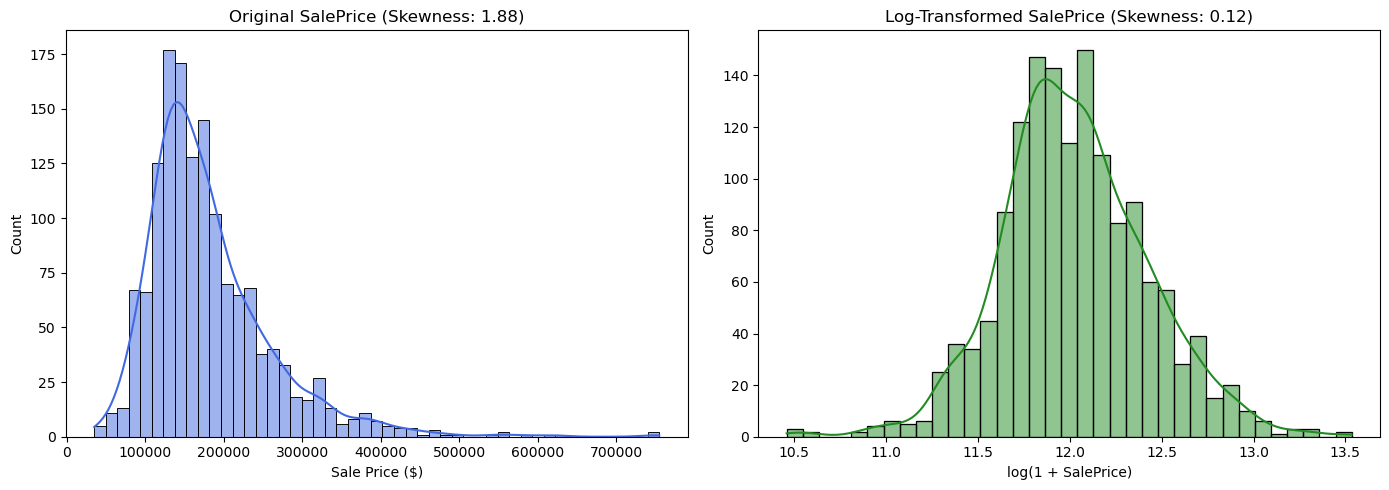

In [4]:
original_skew = df['SalePrice'].skew()
log_price = np.log1p(df['SalePrice'])
log_skew = log_price.skew()

print(f'Original SalePrice Skewness: {original_skew:.2f}')
print(f'Log-transformed SalePrice Skewness: {log_skew:.2f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='royalblue')
axes[0].set_title(f'Original SalePrice (Skewness: {original_skew:.2f})')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Count')


sns.histplot(log_price, kde=True, ax=axes[1], color='forestgreen')
axes[1].set_title(f'Log-Transformed SalePrice (Skewness: {log_skew:.2f})')
axes[1].set_xlabel('log(1 + SalePrice)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

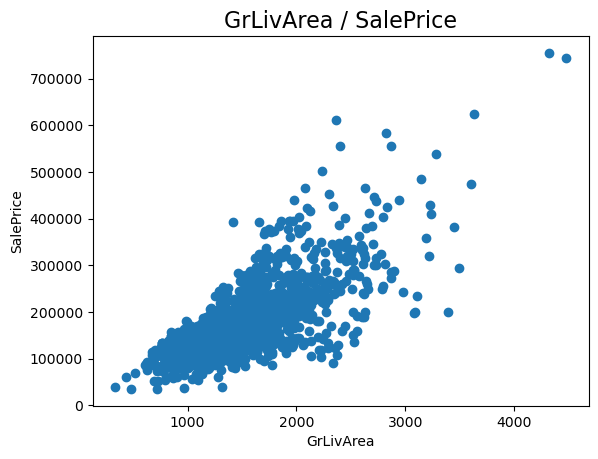

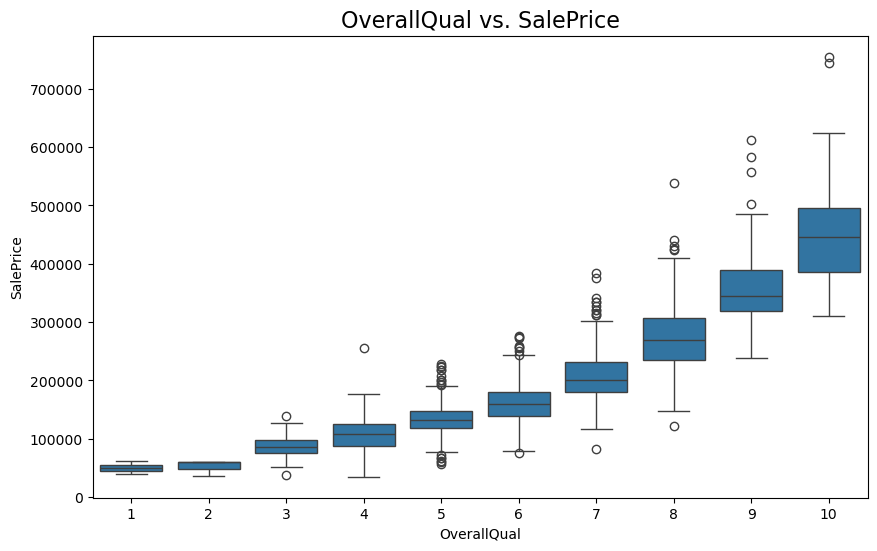

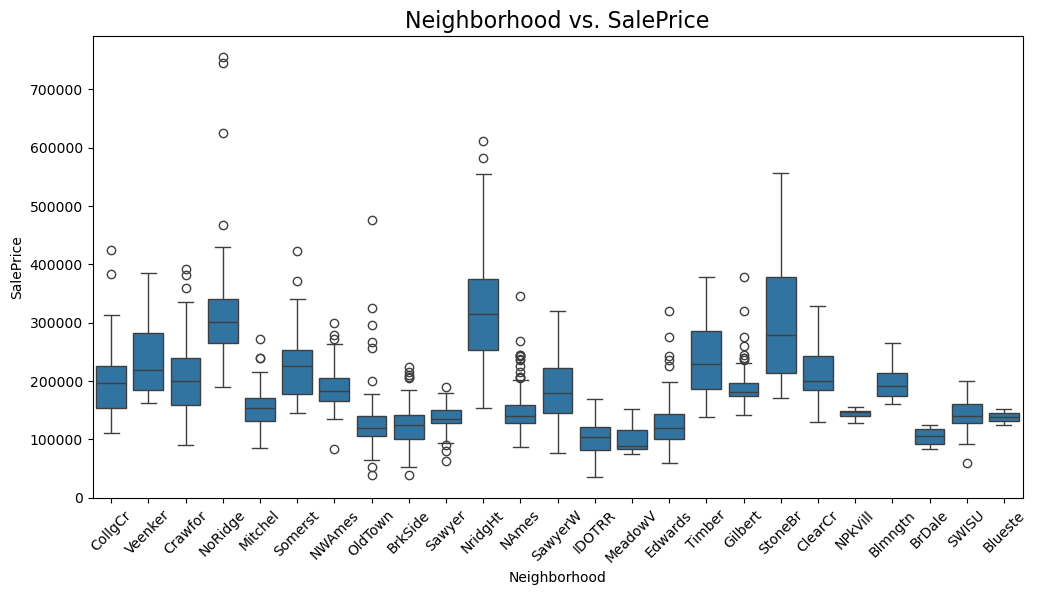

In [5]:
plt.scatter(df['GrLivArea'], df['SalePrice'])

plt.title("GrLivArea / SalePrice",fontsize=16)
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")

plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='OverallQual', y='SalePrice', data=df)
plt.title("OverallQual vs. SalePrice", fontsize=16)
plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.show()


plt.figure(figsize=(12, 6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=df)
plt.xticks(rotation=45) 
plt.title("Neighborhood vs. SalePrice", fontsize=16)
plt.show()

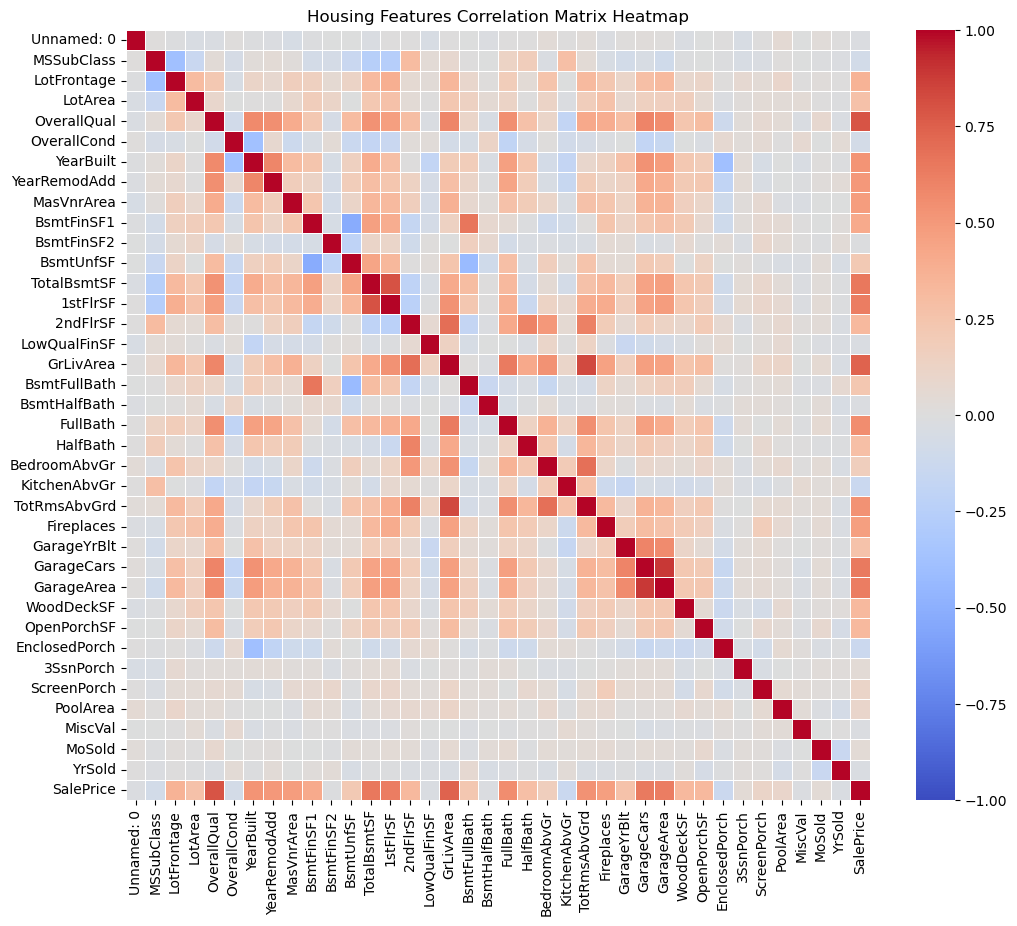

In [6]:

number_column = df.select_dtypes(include=['number']).corr()
# print(number_column)

plt.figure(figsize=(12, 10))

sns.heatmap(
    number_column,
    annot=False,
    cmap='coolwarm',
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)

plt.title('Housing Features Correlation Matrix Heatmap')
plt.show()

In [7]:
#Conceptual Feature Engineering

df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['TotalBath'] = (
    df['BsmtFullBath']
    + (0.5 * df['BsmtHalfBath'])
    + df['FullBath']
    + (0.5 * df['HalfBath'])
)
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

print(df[['TotalSF', 'TotalBath', 'HouseAge', 'RemodAge']].head())


df = df.drop(columns=['TotalBsmtSF','1stFlrSF','2ndFlrSF','BsmtFullBath','BsmtHalfBath','FullBath','HalfBath','YrSold'])
df = pd.get_dummies(df)



df.to_csv("../data/processed/engineered_house_prices.csv", index=False)

   TotalSF  TotalBath  HouseAge  RemodAge
0   2566.0        3.5         5         5
1   2524.0        2.5        31        31
2   2706.0        3.5         7         6
3   2473.0        2.0        91        36
4   3343.0        3.5         8         8
